# Stage 4: Decision-Policy Baselines

This notebook establishes baseline treatment policies before causal machine
learning models are introduced.

The policies are evaluated using the simulator's known response surfaces:

- Treat nobody
- Treat everybody
- Randomly treat 20%
- Oracle targeting

The oracle policy is not deployable because it uses the true conditional
treatment effects. It represents the best achievable policy under the simulated
business constraints and provides an upper bound for future models.

In [18]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIRECTORY
    if (CURRENT_DIRECTORY / "src" / "simulation.py").exists()
    else CURRENT_DIRECTORY.parent
)

SRC_DIRECTORY = PROJECT_ROOT / "src"

if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))

from policies import (
    evaluate_policy,
    oracle_policy,
    random_policy,
    treat_all_policy,
    treat_none_policy,
)
from simulation import simulate_customers

sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 30)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

FIGURE_DIRECTORY = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

RETENTION_VALUE = 80.0
TREATMENT_COST = 10.0
POLICY_CAPACITY = 0.20
RANDOM_SEED = 42

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Samridh\Projects\Causal_Inference


## 1. Create the evaluation cohort

A fixed 70/30 split is created before any model is trained. All policy values
reported in this project will be calculated on the held-out evaluation cohort.

In [19]:
full_data = simulate_customers(
    number_of_customers=20_000,
    seed=RANDOM_SEED,
)

rng = np.random.default_rng(RANDOM_SEED)
shuffled_indices = rng.permutation(len(full_data))

split_position = int(0.70 * len(full_data))

training_indices = shuffled_indices[:split_position]
evaluation_indices = shuffled_indices[split_position:]

training_data = (
    full_data
    .iloc[training_indices]
    .reset_index(drop=True)
)

evaluation_data = (
    full_data
    .iloc[evaluation_indices]
    .reset_index(drop=True)
)

print(f"Training customers:   {len(training_data):,}")
print(f"Evaluation customers: {len(evaluation_data):,}")
print(
    "Evaluation capacity: "
    f"{int(len(evaluation_data) * POLICY_CAPACITY):,}"
)

Training customers:   14,000
Evaluation customers: 6,000
Evaluation capacity: 1,200


## 2. Construct baseline policies

Treat-everybody is included as an economic reference, even though it violates
the 20% capacity constraint. Random and oracle targeting must satisfy the
constraint exactly.

In [20]:
number_of_evaluation_customers = len(evaluation_data)

policy_decisions = {
    "Treat nobody": treat_none_policy(
        number_of_evaluation_customers
    ),
    "Treat everybody": treat_all_policy(
        number_of_evaluation_customers
    ),
    "Random 20%": random_policy(
        population_size=number_of_evaluation_customers,
        capacity=POLICY_CAPACITY,
        seed=RANDOM_SEED,
    ),
    "Oracle 20%": oracle_policy(
        data=evaluation_data,
        capacity=POLICY_CAPACITY,
        retention_value=RETENTION_VALUE,
        treatment_cost=TREATMENT_COST,
    ),
}

decision_summary = pd.DataFrame(
    {
        policy_name: {
            "treated_count": int(decisions.sum()),
            "treatment_rate": float(decisions.mean()),
        }
        for policy_name, decisions in policy_decisions.items()
    }
).T

display(decision_summary)

,treated_count,treatment_rate
Treat nobody,0.0000,0.0000
Treat everybody,"6,000.0000",1.0000
Random 20%,"1,200.0000",0.2000
Oracle 20%,"1,200.0000",0.2000


## 3. Evaluate baseline policy value

Policy value is evaluated from the simulator's true response probabilities.

For customer i, incremental profit from treatment is:

IV_i = 80 × CATE_i - 10

A policy's total incremental profit is the sum of this value over all customers
selected by the policy.

In [21]:
policy_results = []

for policy_name, decisions in policy_decisions.items():
    result = evaluate_policy(
        data=evaluation_data,
        decisions=decisions,
        policy_name=policy_name,
        capacity=POLICY_CAPACITY,
        retention_value=RETENTION_VALUE,
        treatment_cost=TREATMENT_COST,
    )

    policy_results.append(result)

results_table = pd.DataFrame(policy_results)

oracle_profit = results_table.loc[
    results_table["policy"] == "Oracle 20%",
    "incremental_profit",
].iloc[0]

results_table["regret_vs_oracle"] = (
    oracle_profit - results_table["incremental_profit"]
)

results_table["oracle_profit_captured"] = np.where(
    oracle_profit > 0,
    results_table["incremental_profit"] / oracle_profit,
    np.nan,
)

display(
    results_table[
        [
            "policy",
            "treated_count",
            "treatment_rate",
            "capacity_feasible",
            "mean_cate_treated",
            "incremental_retained_customers",
            "incremental_profit",
            "profit_per_treated_customer",
            "regret_vs_oracle",
            "oracle_profit_captured",
        ]
    ].sort_values(
        "incremental_profit",
        ascending=False,
    )
)

,policy,treated_count,treatment_rate,capacity_feasible,mean_cate_treated,incremental_retained_customers,incremental_profit,profit_per_treated_customer,regret_vs_oracle,oracle_profit_captured
3,Oracle 20%,1200,0.2000,True,0.3079,369.4529,"17,556.2281",14.6302,0.0000,1.0000
1,Treat everybody,6000,1.0000,False,0.1562,937.4852,"14,998.8188",2.4998,"2,557.4093",0.8543
2,Random 20%,1200,0.2000,True,0.1574,188.8243,"3,105.9408",2.5883,"14,450.2873",0.1769
0,Treat nobody,0,0.0000,True,0.0000,0.0000,0.0000,0.0000,"17,556.2281",0.0000


In [22]:
assert policy_decisions["Treat nobody"].sum() == 0

assert (
    policy_decisions["Treat everybody"].sum()
    == len(evaluation_data)
)

assert (
    policy_decisions["Random 20%"].sum()
    == int(len(evaluation_data) * POLICY_CAPACITY)
)

assert (
    policy_decisions["Oracle 20%"].sum()
    <= int(len(evaluation_data) * POLICY_CAPACITY)
)

assert results_table.loc[
    results_table["policy"] == "Treat nobody",
    "incremental_profit",
].iloc[0] == 0

assert results_table.loc[
    results_table["policy"] == "Treat everybody",
    "capacity_feasible",
].iloc[0] == False

print("All baseline policy checks passed.")

All baseline policy checks passed.


## 4. Compare policy profitability

Treat-everybody may generate positive total profit, but it is not feasible under
the campaign constraint. Among feasible policies, the oracle represents the
maximum achievable profit.

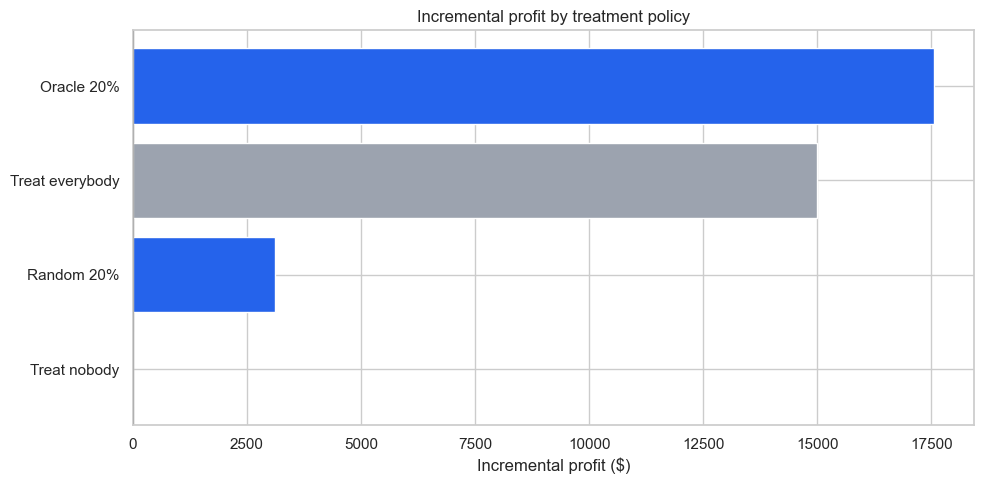

In [23]:
plot_data = results_table.sort_values(
    "incremental_profit",
    ascending=True,
)

colors = [
    "#2563EB" if feasible else "#9CA3AF"
    for feasible in plot_data["capacity_feasible"]
]

fig, axis = plt.subplots(figsize=(10, 5))

axis.barh(
    plot_data["policy"],
    plot_data["incremental_profit"],
    color=colors,
)

axis.axvline(0, color="black", linewidth=0.8)

axis.set(
    title="Incremental profit by treatment policy",
    xlabel="Incremental profit ($)",
    ylabel="",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY / "baseline_policy_profit.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

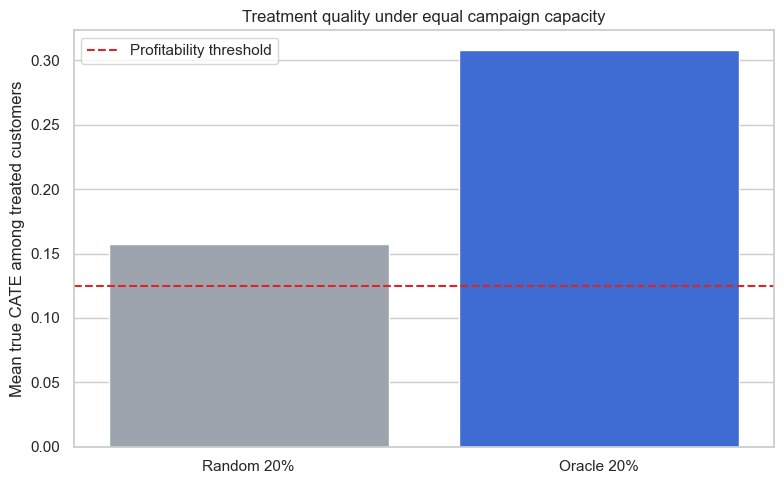

In [24]:
feasible_targeting_policies = results_table[
    results_table["policy"].isin(
        ["Random 20%", "Oracle 20%"]
    )
].copy()

fig, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=feasible_targeting_policies,
    x="policy",
    y="mean_cate_treated",
    hue="policy",
    legend=False,
    palette=["#9CA3AF", "#2563EB"],
    ax=axis,
)

axis.axhline(
    TREATMENT_COST / RETENTION_VALUE,
    color="#DC2626",
    linestyle="--",
    label="Profitability threshold",
)

axis.set(
    title="Treatment quality under equal campaign capacity",
    xlabel="",
    ylabel="Mean true CATE among treated customers",
)

axis.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY / "baseline_treatment_quality.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 5. Random-policy variability

Random targeting is repeated across many seeds to distinguish its expected
performance from variation caused by one random customer selection.

In [25]:
random_policy_results = []

for seed in range(250):
    decisions = random_policy(
        population_size=len(evaluation_data),
        capacity=POLICY_CAPACITY,
        seed=seed,
    )

    result = evaluate_policy(
        data=evaluation_data,
        decisions=decisions,
        policy_name="Random 20%",
        capacity=POLICY_CAPACITY,
        retention_value=RETENTION_VALUE,
        treatment_cost=TREATMENT_COST,
    )

    random_policy_results.append(
        {
            "seed": seed,
            "incremental_profit": result[
                "incremental_profit"
            ],
            "mean_cate_treated": result[
                "mean_cate_treated"
            ],
        }
    )

random_results = pd.DataFrame(random_policy_results)

display(
    random_results[
        ["incremental_profit", "mean_cate_treated"]
    ].describe()
)

,incremental_profit,mean_cate_treated
count,250.0000,250.0000
mean,"2,978.0676",0.1560
std,256.2702,0.0027
min,"2,310.5402",0.1491
25%,"2,788.8841",0.1541
50%,"2,974.6004",0.1560
75%,"3,144.0986",0.1578
max,"3,618.1856",0.1627


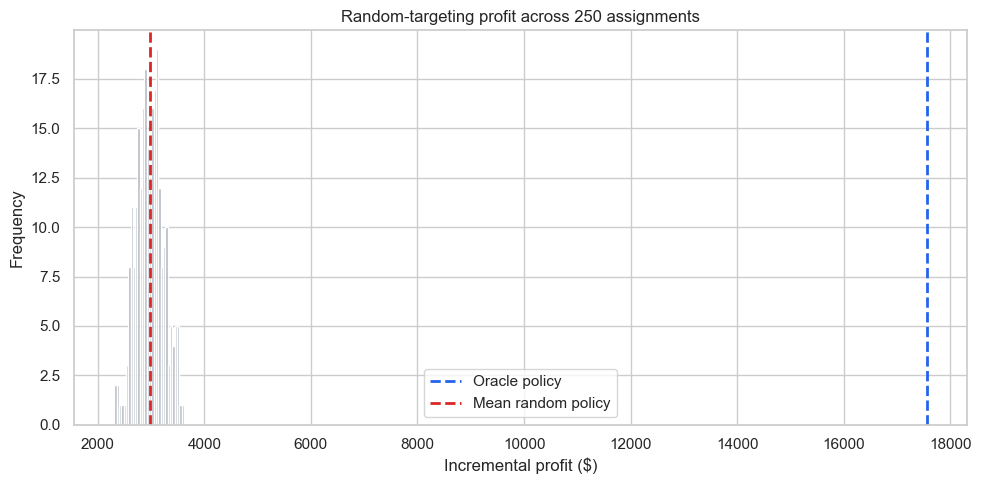

In [26]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=random_results,
    x="incremental_profit",
    bins=30,
    color="#9CA3AF",
    ax=axis,
)

axis.axvline(
    oracle_profit,
    color="#2563EB",
    linestyle="--",
    linewidth=2,
    label="Oracle policy",
)

axis.axvline(
    random_results["incremental_profit"].mean(),
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label="Mean random policy",
)

axis.set(
    title="Random-targeting profit across 250 assignments",
    xlabel="Incremental profit ($)",
    ylabel="Frequency",
)

axis.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY / "random_policy_variability.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [27]:
random_decisions = policy_decisions["Random 20%"]
oracle_decisions = policy_decisions["Oracle 20%"]

selected_by_both = int(
    ((random_decisions == 1) & (oracle_decisions == 1)).sum()
)

oracle_selected = int(oracle_decisions.sum())

overlap_rate = selected_by_both / oracle_selected

print(f"Customers selected by both: {selected_by_both:,}")
print(f"Oracle selection recovered randomly: {overlap_rate:.2%}")

Customers selected by both: 245
Oracle selection recovered randomly: 20.42%


## 6. Interpretation

The baseline policies establish three important reference points:

1. **Treat nobody** produces zero incremental profit and represents the
   no-campaign baseline.

2. **Treat everybody** may create value but violates the 20% campaign-capacity
   constraint. It is an economic reference rather than a feasible policy.

3. **Random targeting** satisfies the constraint but spends campaign budget
   without using customer-level treatment responsiveness.

4. **Oracle targeting** selects customers with the greatest true incremental
   value. It is not deployable because true treatment effects are unavailable
   in real data, but it provides an upper bound for future models.

The difference between random and oracle profit is the value potentially
available from learning treatment-effect heterogeneity.

The next baseline will target customers with the highest predicted churn risk.
That policy will show whether predicting who will leave is equivalent to
predicting who will respond to treatment.

# Stage 4C: Churn-Risk Targeting

A conventional churn model estimates which customers are most likely to leave
without treatment.

This is not the same as estimating which customers will respond to treatment.

To create a strong predictive baseline, the churn model is trained only on
historically untreated customers. This prevents retention offers from changing
the training labels and allows the model to approximate untreated churn risk:

P(Y(0) = 0 | X)

The model never receives true propensity scores, potential-outcome
probabilities, or true treatment effects as features.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [29]:
NUMERIC_FEATURES = [
    "tenure_months",
    "monthly_price",
    "login_days_30d",
    "usage_trend_90d",
    "support_tickets_30d",
    "late_payments_12m",
]

CATEGORICAL_FEATURES = [
    "plan_type",
    "region",
    "device_type",
]

CHURN_FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

FORBIDDEN_MODEL_COLUMNS = {
    "customer_id",
    "treatment",
    "retained_90d",
    "true_propensity",
    "true_mu0",
    "true_mu1",
    "true_cate",
}

assert not set(CHURN_FEATURES).intersection(
    FORBIDDEN_MODEL_COLUMNS
)

print("Model features:")
print(CHURN_FEATURES)

Model features:
['tenure_months', 'monthly_price', 'login_days_30d', 'usage_trend_90d', 'support_tickets_30d', 'late_payments_12m', 'plan_type', 'region', 'device_type']


## 1. Prepare the churn-model training data

The churn model is trained only on untreated historical customers. For these
customers, the observed retention outcome corresponds to the untreated outcome.

The model target is:

- `1`: customer churned
- `0`: customer remained subscribed

In [30]:
untreated_training_data = (
    training_data.loc[
        training_data["treatment"] == 0
    ]
    .copy()
)

X_churn_train = untreated_training_data[
    CHURN_FEATURES
]

y_churn_train = (
    1
    - untreated_training_data["retained_90d"]
)

print(
    "Untreated training customers: "
    f"{len(untreated_training_data):,}"
)

print(
    "Training churn rate: "
    f"{y_churn_train.mean():.2%}"
)

assert set(X_churn_train.columns) == set(
    CHURN_FEATURES
)

assert not set(X_churn_train.columns).intersection(
    FORBIDDEN_MODEL_COLUMNS
)

Untreated training customers: 9,801
Training churn rate: 34.17%


## 2. Train a conventional churn model

Categorical variables are one-hot encoded. A random forest is used because it
can represent nonlinear churn relationships and feature interactions without
using any oracle information.

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)

churn_classifier = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=25,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

churn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", churn_classifier),
    ]
)

churn_pipeline.fit(
    X_churn_train,
    y_churn_train,
)

print("Churn model trained successfully.")

Churn model trained successfully.


## 3. Evaluate churn prediction

Predictive performance is measured among untreated evaluation customers, where
the observed outcome represents retention without the offer.

These metrics evaluate churn prediction—not treatment-effect estimation.

In [32]:
untreated_evaluation_mask = (
    evaluation_data["treatment"] == 0
)

X_churn_evaluation = evaluation_data.loc[
    untreated_evaluation_mask,
    CHURN_FEATURES,
]

y_churn_evaluation = (
    1
    - evaluation_data.loc[
        untreated_evaluation_mask,
        "retained_90d",
    ]
)

predicted_churn_probability_untreated = (
    churn_pipeline.predict_proba(
        X_churn_evaluation
    )[:, 1]
)

churn_metrics = pd.Series(
    {
        "evaluation_customers": len(
            X_churn_evaluation
        ),
        "churn_rate": (
            y_churn_evaluation.mean()
        ),
        "roc_auc": roc_auc_score(
            y_churn_evaluation,
            predicted_churn_probability_untreated,
        ),
        "log_loss": log_loss(
            y_churn_evaluation,
            predicted_churn_probability_untreated,
        ),
        "brier_score": brier_score_loss(
            y_churn_evaluation,
            predicted_churn_probability_untreated,
        ),
    }
)

display(churn_metrics.to_frame("value"))

,value
evaluation_customers,"4,229.0000"
churn_rate,0.3360
roc_auc,0.7352
log_loss,0.5976
brier_score,0.2065


In [33]:
true_untreated_churn_probability = (
    1
    - evaluation_data.loc[
        untreated_evaluation_mask,
        "true_mu0",
    ].to_numpy()
)

risk_correlation = np.corrcoef(
    predicted_churn_probability_untreated,
    true_untreated_churn_probability,
)[0, 1]

print(
    "Correlation with true untreated churn risk: "
    f"{risk_correlation:.3f}"
)

Correlation with true untreated churn risk: 0.952


In [34]:
predicted_churn_probability = (
    churn_pipeline.predict_proba(
        evaluation_data[CHURN_FEATURES]
    )[:, 1]
)

evaluation_data = evaluation_data.copy()

evaluation_data[
    "predicted_churn_probability"
] = predicted_churn_probability

display(
    evaluation_data[
        [
            "customer_id",
            "predicted_churn_probability",
            "true_mu0",
            "true_cate",
        ]
    ].head()
)

,customer_id,predicted_churn_probability,true_mu0,true_cate
0,16921,0.7291,0.2717,0.1059
1,14853,0.7109,0.3644,0.2762
2,14387,0.3550,0.7488,0.1172
3,14402,0.3344,0.7195,0.1479
4,6099,0.5999,0.4463,0.1868


In [35]:
churn_risk_decisions = top_score_policy(
    scores=predicted_churn_probability,
    capacity=POLICY_CAPACITY,
    require_positive=False,
)

policy_decisions["Churn risk 20%"] = (
    churn_risk_decisions
)

assert (
    churn_risk_decisions.sum()
    == int(
        len(evaluation_data)
        * POLICY_CAPACITY
    )
)

print(
    "Customers selected by churn policy: "
    f"{churn_risk_decisions.sum():,}"
)

Customers selected by churn policy: 1,200


In [36]:
policy_results = []

for policy_name, decisions in policy_decisions.items():
    result = evaluate_policy(
        data=evaluation_data,
        decisions=decisions,
        policy_name=policy_name,
        capacity=POLICY_CAPACITY,
        retention_value=RETENTION_VALUE,
        treatment_cost=TREATMENT_COST,
    )

    policy_results.append(result)

results_table = pd.DataFrame(policy_results)

oracle_profit = results_table.loc[
    results_table["policy"] == "Oracle 20%",
    "incremental_profit",
].iloc[0]

results_table["regret_vs_oracle"] = (
    oracle_profit
    - results_table["incremental_profit"]
)

results_table["oracle_profit_captured"] = np.where(
    oracle_profit > 0,
    (
        results_table["incremental_profit"]
        / oracle_profit
    ),
    np.nan,
)

results_table = results_table.sort_values(
    "incremental_profit",
    ascending=False,
)

display(
    results_table[
        [
            "policy",
            "treated_count",
            "treatment_rate",
            "capacity_feasible",
            "mean_cate_treated",
            "incremental_retained_customers",
            "incremental_profit",
            "profit_per_treated_customer",
            "regret_vs_oracle",
            "oracle_profit_captured",
        ]
    ]
)

,policy,treated_count,treatment_rate,capacity_feasible,mean_cate_treated,incremental_retained_customers,incremental_profit,profit_per_treated_customer,regret_vs_oracle,oracle_profit_captured
3,Oracle 20%,1200,0.2000,True,0.3079,369.4529,"17,556.2281",14.6302,0.0000,1.0000
1,Treat everybody,6000,1.0000,False,0.1562,937.4852,"14,998.8188",2.4998,"2,557.4093",0.8543
4,Churn risk 20%,1200,0.2000,True,0.2609,313.0312,"13,042.4953",10.8687,"4,513.7328",0.7429
2,Random 20%,1200,0.2000,True,0.1574,188.8243,"3,105.9408",2.5883,"14,450.2873",0.1769
0,Treat nobody,0,0.0000,True,0.0000,0.0000,0.0000,0.0000,"17,556.2281",0.0000


In [37]:
churn_cate_correlation = np.corrcoef(
    predicted_churn_probability,
    evaluation_data["true_cate"],
)[0, 1]

print(
    "Correlation between predicted churn risk "
    "and true treatment effect: "
    f"{churn_cate_correlation:.3f}"
)

Correlation between predicted churn risk and true treatment effect: 0.784


In [38]:
oracle_decisions = policy_decisions[
    "Oracle 20%"
]

selected_by_both = int(
    (
        (churn_risk_decisions == 1)
        & (oracle_decisions == 1)
    ).sum()
)

oracle_selected_count = int(
    oracle_decisions.sum()
)

oracle_recovery_rate = (
    selected_by_both
    / oracle_selected_count
)

union_count = int(
    (
        (churn_risk_decisions == 1)
        | (oracle_decisions == 1)
    ).sum()
)

jaccard_similarity = (
    selected_by_both / union_count
)

selection_comparison = pd.Series(
    {
        "selected by churn policy": (
            churn_risk_decisions.sum()
        ),
        "selected by oracle": (
            oracle_selected_count
        ),
        "selected by both": selected_by_both,
        "oracle recovery rate": (
            oracle_recovery_rate
        ),
        "Jaccard similarity": (
            jaccard_similarity
        ),
    }
)

display(
    selection_comparison.to_frame("value")
)

,value
selected by churn policy,"1,200.0000"
selected by oracle,"1,200.0000"
selected by both,701.0000
oracle recovery rate,0.5842
Jaccard similarity,0.4126


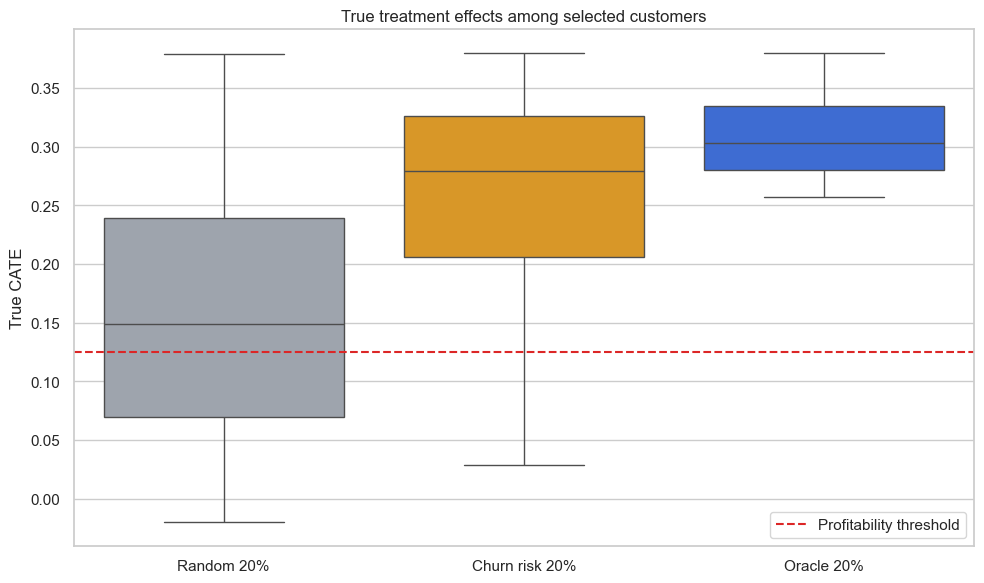

In [39]:
selection_quality_rows = []

for policy_name in [
    "Random 20%",
    "Churn risk 20%",
    "Oracle 20%",
]:
    decisions = policy_decisions[policy_name]

    selected_effects = evaluation_data.loc[
        decisions == 1,
        "true_cate",
    ]

    for treatment_effect in selected_effects:
        selection_quality_rows.append(
            {
                "policy": policy_name,
                "true_cate": treatment_effect,
            }
        )

selection_quality = pd.DataFrame(
    selection_quality_rows
)

fig, axis = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=selection_quality,
    x="policy",
    y="true_cate",
    hue="policy",
    legend=False,
    showfliers=False,
    palette=[
        "#9CA3AF",
        "#F59E0B",
        "#2563EB",
    ],
    ax=axis,
)

axis.axhline(
    TREATMENT_COST / RETENTION_VALUE,
    color="#DC2626",
    linestyle="--",
    label="Profitability threshold",
)

axis.set(
    title=(
        "True treatment effects among "
        "selected customers"
    ),
    xlabel="",
    ylabel="True CATE",
)

axis.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "churn_vs_oracle_treatment_quality.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

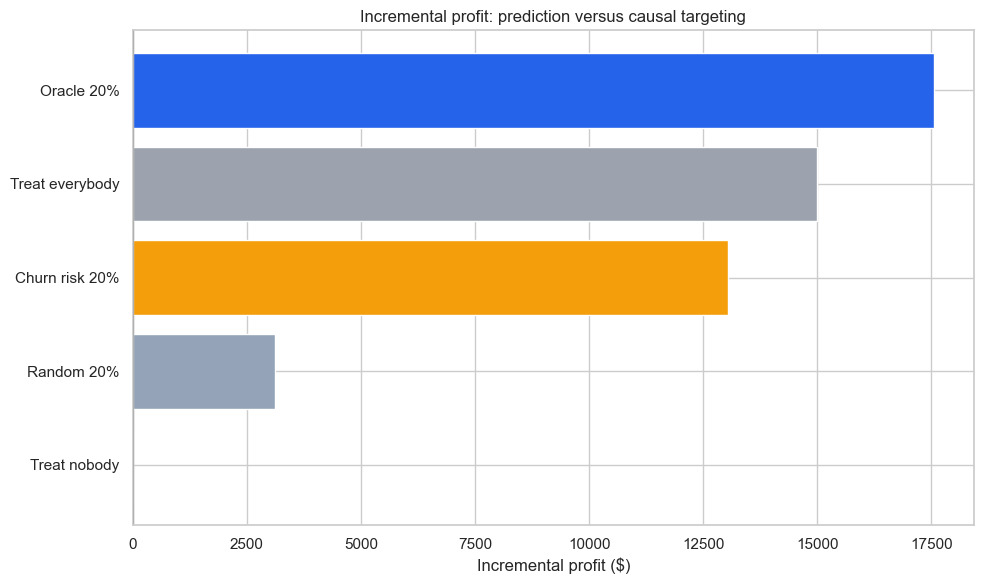

In [40]:
plot_data = results_table.sort_values(
    "incremental_profit",
    ascending=True,
)

colors = {
    "Treat nobody": "#6B7280",
    "Treat everybody": "#9CA3AF",
    "Random 20%": "#94A3B8",
    "Churn risk 20%": "#F59E0B",
    "Oracle 20%": "#2563EB",
}

fig, axis = plt.subplots(figsize=(10, 6))

axis.barh(
    plot_data["policy"],
    plot_data["incremental_profit"],
    color=[
        colors[policy]
        for policy in plot_data["policy"]
    ],
)

axis.axvline(
    0,
    color="black",
    linewidth=0.8,
)

axis.set(
    title=(
        "Incremental profit: prediction "
        "versus causal targeting"
    ),
    xlabel="Incremental profit ($)",
    ylabel="",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "churn_policy_profit_comparison.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [41]:
churn_policy_result = results_table.loc[
    results_table["policy"]
    == "Churn risk 20%"
].iloc[0]

oracle_result = results_table.loc[
    results_table["policy"]
    == "Oracle 20%"
].iloc[0]

stage_4c_checks = {
    "training and evaluation customers are disjoint": (
        set(training_data["customer_id"]).isdisjoint(
            set(evaluation_data["customer_id"])
        )
    ),
    "oracle columns excluded from model": (
        not set(CHURN_FEATURES).intersection(
            FORBIDDEN_MODEL_COLUMNS
        )
    ),
    "model trained only on untreated customers": (
        untreated_training_data["treatment"]
        .eq(0)
        .all()
    ),
    "churn policy treats exactly 20%": (
        churn_risk_decisions.sum()
        == int(
            len(evaluation_data)
            * POLICY_CAPACITY
        )
    ),
    "churn policy is capacity feasible": bool(
        churn_policy_result[
            "capacity_feasible"
        ]
    ),
    "oracle profit is at least churn-policy profit": (
        oracle_result["incremental_profit"]
        >= churn_policy_result[
            "incremental_profit"
        ]
    ),
    "churn model ranks better than chance": (
        churn_metrics["roc_auc"] > 0.50
    ),
}

stage_4c_table = pd.DataFrame(
    {
        "criterion": stage_4c_checks.keys(),
        "passed": stage_4c_checks.values(),
    }
)

display(stage_4c_table)

assert stage_4c_table["passed"].all()

print("Stage 4C checks passed.")

,criterion,passed
0,training and evaluation customers are disjoint,True
1,oracle columns excluded from model,True
2,model trained only on untreated customers,True
3,churn policy treats exactly 20%,True
4,churn policy is capacity feasible,True
5,oracle profit is at least churn-policy profit,True
6,churn model ranks better than chance,True


Stage 4C checks passed.


## Interpretation

The churn model estimates untreated outcome risk and may perform well according
to conventional predictive metrics such as ROC AUC.

However, churn-risk targeting and causal targeting solve different problems:

- Churn-risk targeting asks who is likely to leave.
- Causal targeting asks whose outcome will improve because of treatment.

Customers at the highest churn risk may be too disengaged to respond to a
discount. Customers at low risk may renew without one. The most valuable group
is generally the persuadable middle.

The oracle policy's advantage over churn-risk targeting quantifies the value
available from estimating heterogeneous treatment effects rather than outcome
risk alone.